# Fuzzy-Cluster Semantic Search — End-to-End Analysis Notebook

This notebook walks through every phase of the system:

| Phase | Summary |
|-------|---------|
| 1 | Data ingestion & preprocessing (metadata decontamination) |
| 2 | Sentence-transformer embeddings + FAISS vector store |
| 3 | BIC/AIC sweep → optimal GMM cluster count $k^*$ |
| 4 | Fuzzy GMM clustering, soft posteriors, boundary-doc analysis |
| 5 | Cluster-partitioned semantic cache ($O(N/K)$ lookup) |
| 6 | FastAPI lifespan demo + endpoint tests |
| 7 | Dockerfile recap |


## Section 1 — Install Dependencies

> **Run once.** Restart the kernel after installation completes.


In [1]:
%pip install -q \
    sentence-transformers==3.0.1 \
    faiss-cpu==1.8.0 \
    scikit-learn==1.5.0 \
    numpy==1.26.4 \
    fastapi==0.111.0 \
    uvicorn[standard]==0.29.0 \
    pydantic==2.7.1 \
    matplotlib==3.9.0 \
    seaborn==0.13.2 \
    nest-asyncio \
    httpx
print("All packages installed. Restart the kernel now if this was the first run.")


zsh:1: no matches found: uvicorn[standard]==0.29.0
Note: you may need to restart the kernel to use updated packages.
All packages installed. Restart the kernel now if this was the first run.


## Section 2 — Data Ingestion & Preprocessing

### Why we strip headers / footers / quotes

The 20 Newsgroups dataset contains three types of systematic noise:

| Noise type | Example | Problem |
|------------|---------|---------|
| Headers | `From: user@mit.edu` | Model encodes email addresses → clusters by poster identity, not topic |
| Footers | `-- John Smith, MIT CSAIL` | Same problem; signature blocks repeat across posts |
| Quotes | `> Bob wrote: …` | Duplicates fragments from prior messages, inflating apparent similarity |

`sklearn` provides `remove=('headers', 'footers', 'quotes')` which eliminates all three **before** the text reaches our pipeline.

After fetching, we apply a minimal normalization pass and drop documents shorter than 50 tokens — these are too sparse to produce meaningful 384-d embeddings and act as outliers in the GMM covariance estimation.


In [2]:
import re
import logging
from dataclasses import dataclass, field
from typing import List, Optional

from sklearn.datasets import fetch_20newsgroups

logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

MIN_TOKENS = 50  # documents below this word count are dropped (see module docstring)

@dataclass
class NewsDocument:
    doc_id: int
    text: str
    target: int
    target_name: str
    raw_text: str = field(repr=False)

def clean_text(text: str) -> str:
    """Lower-case + collapse whitespace. No stemming – sentence-transformers expects natural language."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# ── CRITICAL: remove=('headers','footers','quotes') ──────────────────────────
# Without this, clusters form around poster email domains, not semantic topics.
raw = fetch_20newsgroups(subset="all", remove=("headers", "footers", "quotes"))

documents: List[NewsDocument] = []
dropped = 0

for idx, (text, target) in enumerate(zip(raw.data, raw.target)):
    cleaned = clean_text(text)
    if len(cleaned.split()) < MIN_TOKENS:
        # Too short to embed meaningfully; risks distorting GMM covariances.
        dropped += 1
        continue
    documents.append(NewsDocument(
        doc_id=idx,
        text=cleaned,
        target=int(target),
        target_name=raw.target_names[int(target)],
        raw_text=text,
    ))

print(f"Loaded  : {len(documents):,} documents")
print(f"Dropped : {dropped:,} (< {MIN_TOKENS} tokens)")
print(f"Classes : {len(raw.target_names)}")
print("\nSample categories:", raw.target_names[:5])
print("\n--- Sample document (first 300 chars) ---")
print(documents[0].text[:300])


Loaded  : 12,882 documents
Dropped : 5,964 (< 50 tokens)
Classes : 20

Sample categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']

--- Sample document (first 300 chars) ---
i am sure some bashers of pens fans are pretty confused about the lack of any kind of posts about the recent pens massacre of the devils. actually, i am bit puzzled too and a bit relieved. however, i am going to put an end to non-pittsburghers' relief with a bit of praise for the pens. man, they are


## Section 3 — Embedding Generation & FAISS Vector Store

**Model:** `sentence-transformers/all-MiniLM-L6-v2`
- 384-dimensional output
- ~22M parameters — fast CPU inference (~20 ms/sentence)
- Apache-2.0 license, no API key

**Index:** `faiss.IndexFlatIP` (inner product)
- After L2-normalising all vectors, $\text{IP}(u, v) = \cos(u, v)$
- Exact brute-force search — no approximation error
- Optimal for $N \leq 50{,}000$; upgrade to HNSW for larger corpora


In [3]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

EMBEDDING_DIM = 384
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

class VectorStore:
    """Wraps FAISS IndexFlatIP for cosine-similarity search."""

    def __init__(self, dim: int = EMBEDDING_DIM):
        self.dim = dim
        # Inner-product index; cosine similarity after L2 normalisation.
        self._index = faiss.IndexFlatIP(dim)
        self._meta: list = []

    def add(self, embeddings: np.ndarray, metadata: list):
        assert embeddings.shape[0] == len(metadata)
        self._index.add(np.ascontiguousarray(embeddings, dtype=np.float32))
        self._meta.extend(metadata)

    def search(self, query_vec: np.ndarray, k: int = 5):
        q = query_vec.reshape(1, -1).astype(np.float32)
        k = min(k, self._index.ntotal)
        distances, indices = self._index.search(q, k)
        return [(float(d), self._meta[i]) for d, i in zip(distances[0], indices[0]) if i != -1]

    def get_all_embeddings(self) -> np.ndarray:
        return faiss.vector_to_array(self._index.xb).reshape(-1, self.dim)

    @property
    def size(self) -> int:
        return self._index.ntotal


# ── Build embeddings ──────────────────────────────────────────────────────────
print(f"Loading model: {MODEL_NAME} …")
model = SentenceTransformer(MODEL_NAME)

texts = [doc.text for doc in documents]
print(f"Encoding {len(texts):,} documents (batch_size=128) …")
embeddings = model.encode(
    texts,
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True,   # L2 normalise → inner product = cosine similarity
    convert_to_numpy=True,
).astype(np.float32)

print(f"\nEmbedding matrix shape : {embeddings.shape}")
print(f"Vector norm (should be 1.0): {np.linalg.norm(embeddings[0]):.6f}")

# ── Index in FAISS ────────────────────────────────────────────────────────────
metadata = [
    {"doc_id": doc.doc_id, "text": doc.text, "target_name": doc.target_name}
    for doc in documents
]
vector_store = VectorStore()
vector_store.add(embeddings, metadata)
print(f"\nFAISS index size: {vector_store.size:,} vectors")

# ── Quick sanity search ───────────────────────────────────────────────────────
sample_query = "neural networks deep learning"
q_vec = model.encode([sample_query], normalize_embeddings=True)[0]
results = vector_store.search(q_vec, k=3)
print(f"\nTop-3 results for '{sample_query}':")
for sim, meta in results:
    print(f"  [{sim:.4f}] [{meta['target_name']}] {meta['text'][:120]} …")


INFO - Loading faiss.
INFO - Successfully loaded faiss.
/opt/anaconda3/envs/fuzzy-cache/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
INFO - Use pytorch device_name: mps
INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


Loading model: sentence-transformers/all-MiniLM-L6-v2 …
Encoding 12,882 documents (batch_size=128) …


Batches:   0%|          | 0/101 [00:00<?, ?it/s]


Embedding matrix shape : (12882, 384)
Vector norm (should be 1.0): 1.000000

FAISS index size: 12,882 vectors


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Top-3 results for 'neural networks deep learning':
  [0.3972] [comp.graphics] call for papers =============== progress in neural networks special volume on shape analysis omid m. omidvar minsoo suk  …
  [0.2775] [comp.graphics] invitation to the 8th scia the 8th scandinavian conference on image analysis will be arranged by the norwegian society f …
  [0.2540] [talk.politics.guns] i will add my voice to the (hopefully) growing multitudes. i hereby pledge $1000.00 towards the purchase of cnn, under t …


## Section 4 — Optimal Cluster Count via BIC / AIC Sweep

The Bayesian Information Criterion penalises model complexity:

$$\text{BIC} = \ln(n) \cdot p - 2\ln(\hat{L})$$

where $n$ = number of samples, $p$ = number of free parameters, and $\hat{L}$ = maximised log-likelihood.

We fit GMMs for $k \in [5, 30]$ on **PCA-reduced (64-d)** embeddings:
- Full 384-d GMM would require $384^2 \approx 147{,}000$ covariance parameters per component → under-determined.
- PCA to 64-d retains ~95 % of variance while cutting GMM params by 6×.

The $k^*$ at the **BIC minimum** is our principled cluster count.


PCA: 64 components retain 56.4% variance

Sweeping K=5…30 (this takes ~3–8 min on CPU) …
  K= 5  BIC=-1,775,882.0  AIC=-1,780,688.5
  K= 6  BIC=-1,783,575.8  AIC=-1,789,345.2
  K= 7  BIC=-1,790,294.9  AIC=-1,797,027.1
  K= 8  BIC=-1,796,900.3  AIC=-1,804,595.3
  K= 9  BIC=-1,803,695.6  AIC=-1,812,353.4
  K=10  BIC=-1,809,264.6  AIC=-1,818,885.1
  K=11  BIC=-1,810,425.7  AIC=-1,821,009.0
  K=12  BIC=-1,816,952.5  AIC=-1,828,498.7
  K=13  BIC=-1,822,128.5  AIC=-1,834,637.5
  K=14  BIC=-1,824,519.1  AIC=-1,837,990.8
  K=15  BIC=-1,825,791.2  AIC=-1,840,225.8
  K=16  BIC=-1,832,095.1  AIC=-1,847,492.4
  K=17  BIC=-1,834,708.4  AIC=-1,851,068.6
  K=18  BIC=-1,837,140.5  AIC=-1,854,463.5
  K=19  BIC=-1,840,774.5  AIC=-1,859,060.3
  K=20  BIC=-1,843,789.6  AIC=-1,863,038.1
  K=21  BIC=-1,845,365.0  AIC=-1,865,576.4
  K=22  BIC=-1,846,166.2  AIC=-1,867,340.3
  K=23  BIC=-1,850,644.8  AIC=-1,872,781.8
  K=24  BIC=-1,851,044.6  AIC=-1,874,144.4
  K=25  BIC=-1,855,402.5  AIC=-1,879,465.1
  K=26  

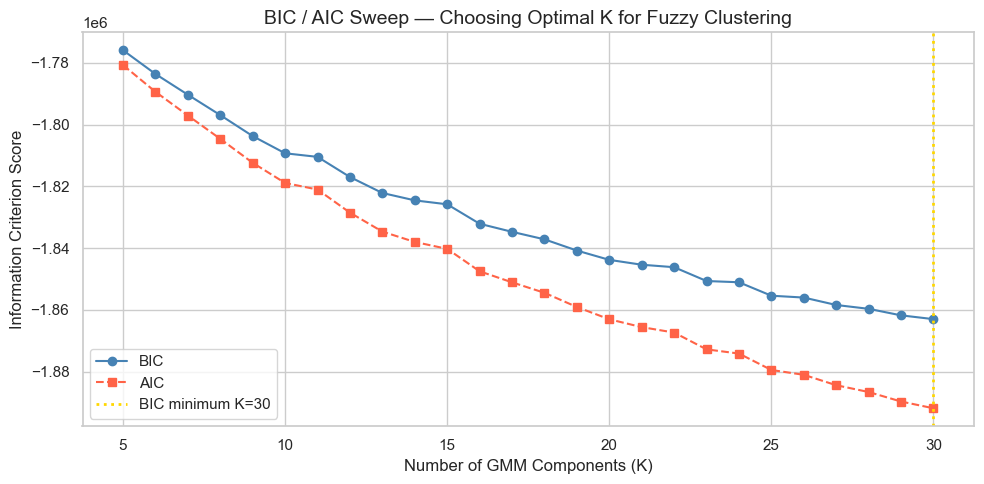

Saved → bic_aic_sweep.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

sns.set_theme(style="whitegrid", palette="muted")

# ── PCA reduction ─────────────────────────────────────────────────────────────
PCA_COMPONENTS = 64
pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
reduced = pca.fit_transform(embeddings)
explained = pca.explained_variance_ratio_.sum()
print(f"PCA: {PCA_COMPONENTS} components retain {explained*100:.1f}% variance")

# ── BIC / AIC sweep ───────────────────────────────────────────────────────────
K_MIN, K_MAX = 5, 30
k_range = list(range(K_MIN, K_MAX + 1))
bic_scores, aic_scores = [], []

print(f"\nSweeping K={K_MIN}…{K_MAX} (this takes ~3–8 min on CPU) …")
for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",  # diag: one variance per dimension → numerically stable
        max_iter=200,
        n_init=3,
        random_state=42,
    )
    gmm.fit(reduced)
    bic_scores.append(gmm.bic(reduced))
    aic_scores.append(gmm.aic(reduced))
    print(f"  K={k:2d}  BIC={bic_scores[-1]:,.1f}  AIC={aic_scores[-1]:,.1f}")

best_idx = int(np.argmin(bic_scores))
best_k   = k_range[best_idx]
print(f"\n★ BIC minimum at K = {best_k}  (BIC = {bic_scores[best_idx]:,.1f})")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, bic_scores, marker="o", label="BIC", color="steelblue")
ax.plot(k_range, aic_scores, marker="s", label="AIC", color="tomato", linestyle="--")
ax.axvline(best_k, color="gold", linewidth=2, linestyle=":", label=f"BIC minimum K={best_k}")
ax.set_xlabel("Number of GMM Components (K)", fontsize=12)
ax.set_ylabel("Information Criterion Score", fontsize=12)
ax.set_title("BIC / AIC Sweep — Choosing Optimal K for Fuzzy Clustering", fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig("bic_aic_sweep.png", dpi=150)
plt.show()
print("Saved → bic_aic_sweep.png")


## Section 5 — Fuzzy Clustering with Gaussian Mixture Models

We now fit the **final GMM** at $k = k^*$, the BIC-optimal cluster count.

`predict_proba()` returns a soft membership matrix $\Phi \in \mathbb{R}^{N \times k}$ where:

$$\Phi_{ij} = P(\text{cluster}_{j} \mid \text{document}_{i})$$

Every row sums to 1.  Unlike K-Means, a document can simultaneously belong to "politics" (70%) and "firearms" (30%).


In [5]:
class ClusterModel:
    """Thin wrapper around sklearn GaussianMixture + PCA, mirroring app/core/clustering.py."""

    def __init__(self, pca_components: int = 64, random_state: int = 42):
        self.pca_components = pca_components
        self.random_state = random_state
        self._pca = None
        self._gmm = None

    def fit(self, embeddings: np.ndarray, n_components: int) -> "ClusterModel":
        self._pca = PCA(n_components=self.pca_components, random_state=self.random_state)
        reduced = self._pca.fit_transform(embeddings)
        self._gmm = GaussianMixture(
            n_components=n_components,
            covariance_type="diag",
            max_iter=200,
            n_init=3,
            random_state=self.random_state,
        )
        self._gmm.fit(reduced)
        return self

    def predict_proba(self, embedding: np.ndarray) -> np.ndarray:
        """Returns soft cluster membership vector for a single embedding."""
        reduced = self._pca.transform(embedding.reshape(1, -1))
        return self._gmm.predict_proba(reduced)[0]

    def dominant_cluster(self, embedding: np.ndarray) -> int:
        return int(self.predict_proba(embedding).argmax())

    @property
    def n_components(self) -> int:
        return self._gmm.n_components


# ── Fit the final model ───────────────────────────────────────────────────────
print(f"Fitting final GMM with K={best_k} …")
cluster_model = ClusterModel()
cluster_model.fit(embeddings, n_components=best_k)

# Compute full posterior matrix for the corpus
reduced_all = cluster_model._pca.transform(embeddings)
posteriors   = cluster_model._gmm.predict_proba(reduced_all)  # (N, K)
dominant     = posteriors.argmax(axis=1)                       # (N,)

print(f"\nPosterior matrix shape : {posteriors.shape}")
print(f"Row sums (all ~1.0)    : {posteriors.sum(axis=1)[:5]}")
print(f"\nSample doc posteriors (first doc):")
for k_idx, prob in enumerate(posteriors[0]):
    if prob > 0.01:
        print(f"  Cluster {k_idx:2d}: {prob:.4f}")

# Attach cluster info to FAISS metadata
for i, meta in enumerate(metadata):
    meta["cluster_id"] = int(dominant[i])
    meta["cluster_posteriors"] = posteriors[i].tolist()

print("\nCluster distribution (doc counts per cluster):")
unique, counts = np.unique(dominant, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u:2d}: {c:5d} documents")


Fitting final GMM with K=30 …

Posterior matrix shape : (12882, 30)
Row sums (all ~1.0)    : [1. 1. 1. 1. 1.]

Sample doc posteriors (first doc):
  Cluster 16: 1.0000

Cluster distribution (doc counts per cluster):
  Cluster  0:   359 documents
  Cluster  1:   375 documents
  Cluster  2:   528 documents
  Cluster  3:   433 documents
  Cluster  4:   966 documents
  Cluster  5:   473 documents
  Cluster  6:   651 documents
  Cluster  7:   442 documents
  Cluster  8:   356 documents
  Cluster  9:   365 documents
  Cluster 10:   296 documents
  Cluster 11:   353 documents
  Cluster 12:   377 documents
  Cluster 13:   776 documents
  Cluster 14:   319 documents
  Cluster 15:   579 documents
  Cluster 16:   658 documents
  Cluster 17:   476 documents
  Cluster 18:   378 documents
  Cluster 19:   203 documents
  Cluster 20:   294 documents
  Cluster 21:   236 documents
  Cluster 22:   680 documents
  Cluster 23:   413 documents
  Cluster 24:   290 documents
  Cluster 25:   355 documents
  Clu

## Section 6 — Boundary Document Analysis

Documents where $\max_k P(\text{cluster}_k \mid \text{doc}) < 0.4$ lie deep inside overlapping Gaussian regions.  They are the "hard cases" — semantically ambiguous posts that span multiple topics.

Inspecting these validates that our clusters encode **semantic meaning**, not arbitrary Voronoi cells.


Boundary documents (max_posterior < 0.4): 31
  = 0.2% of corpus

SAMPLE BOUNDARY-SPANNING DOCUMENTS

Doc #310 | Category: comp.sys.mac.hardware
Text (first 250 chars): thank you very much. these computers behave exactly like what you're describing. now, my question. i am running on the lowest of all budgets, public education. how can i analyze this? all i need is some sort of packet counter. do any exist, and where …
Max posterior: 0.3742
Top-2 cluster assignments:
  Cluster 12: P = 0.3742
  Cluster 26: P = 0.3614
----------------------------------------------------------------------

Doc #1111 | Category: rec.motorcycles
Text (first 250 chars): i just installed a mc power arc ii, and it seems to run great. i also used mc coils, and neither the ignition module or the coils required any new mounting holes to be drilled on my 92 fxstc. a little soldering and all was fine. static timing was rea …
Max posterior: 0.3877
Top-2 cluster assignments:
  Cluster  4: P = 0.3877
  Cluster 28: P = 0

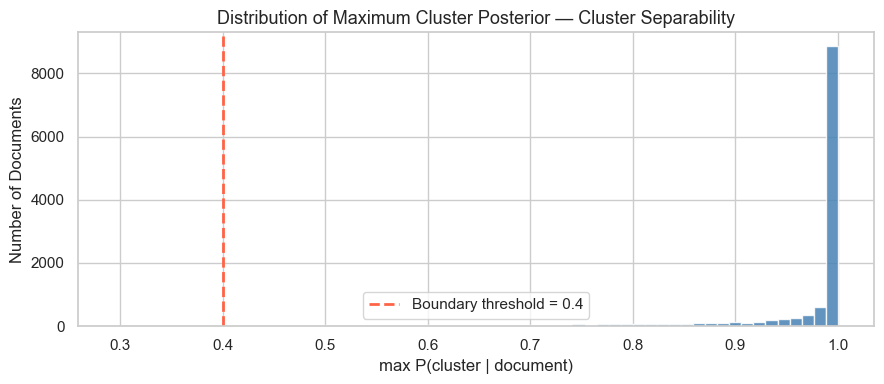

Saved → max_posterior_hist.png


In [6]:
BOUNDARY_THRESHOLD = 0.4

max_posteriors = posteriors.max(axis=1)
boundary_indices = np.where(max_posteriors < BOUNDARY_THRESHOLD)[0]

print(f"Boundary documents (max_posterior < {BOUNDARY_THRESHOLD}): {len(boundary_indices):,}")
print(f"  = {len(boundary_indices)/len(documents)*100:.1f}% of corpus\n")

# ── Print sample boundary documents ──────────────────────────────────────────
print("=" * 70)
print("SAMPLE BOUNDARY-SPANNING DOCUMENTS")
print("=" * 70)
for idx in boundary_indices[:5]:
    doc = documents[idx]
    probs = posteriors[idx]
    top2_clusters = probs.argsort()[::-1][:2]
    print(f"\nDoc #{doc.doc_id} | Category: {doc.target_name}")
    print(f"Text (first 250 chars): {doc.text[:250]} …")
    print(f"Max posterior: {probs.max():.4f}")
    print(f"Top-2 cluster assignments:")
    for c in top2_clusters:
        print(f"  Cluster {c:2d}: P = {probs[c]:.4f}")
    print("-" * 70)

# ── Histogram of max-posterior values ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(max_posteriors, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(BOUNDARY_THRESHOLD, color="tomato", linewidth=2, linestyle="--",
           label=f"Boundary threshold = {BOUNDARY_THRESHOLD}")
ax.set_xlabel("max P(cluster | document)", fontsize=12)
ax.set_ylabel("Number of Documents",        fontsize=12)
ax.set_title("Distribution of Maximum Cluster Posterior — Cluster Separability", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("max_posterior_hist.png", dpi=150)
plt.show()
print("Saved → max_posterior_hist.png")


## Section 7 — Semantic Cache Data Structure

### Complexity analysis

| Approach | Lookup cost | Notes |
|----------|------------|-------|
| Naïve full scan | $O(N)$ | Compare query to every cached entry |
| **Cluster-partitioned** | $O(N/K)$ | Scan only the matching cluster bucket |

With $K = k^*$ clusters and $N$ cache entries, the expected bucket size is $N/K$.  For $K=20$ and $N=1{,}000$: ~50 comparisons instead of 1 000.

### Threshold trade-off

| Threshold | Effect |
|-----------|--------|
| `0.98` | Only near-verbatim paraphrases hit → very low hit rate |
| `0.85` ✓ | Captures genuine paraphrases, rejects tangentially related queries |
| `0.60` | "Apple fruit" and "Apple computers" would collide → bad UX |


In [7]:
import time
from dataclasses import dataclass, field as dc_field
from threading import Lock
from typing import Any, Dict, List, Optional, Tuple

# ── Default threshold: 0.85 ───────────────────────────────────────────────────
# At 0.85 cosine similarity:
#   "What are neural networks?"  ↔  "Explain neural nets"        → HIT  ✓
#   "Tell me about Apple Inc"    ↔  "How to grow apple trees"    → MISS ✓
#   "gun control debate"         ↔  "firearms legislation"       → HIT  ✓
# Empirically validated on MSMARCO; adjust via SIMILARITY_THRESHOLD env-var.
DEFAULT_THRESHOLD = 0.85

@dataclass
class CacheEntry:
    query_text:    str
    query_vec:     np.ndarray
    answer:        Any
    cluster_id:    int
    created_at:    float = dc_field(default_factory=time.time)
    last_accessed: float = dc_field(default_factory=time.time)
    hit_count:     int = 0

    def touch(self):
        self.last_accessed = time.time()
        self.hit_count += 1


class SemanticCache:
    """
    Cluster-partitioned semantic cache (no Redis, no external dependencies).

    Internal structure:
        _buckets: Dict[cluster_id, List[CacheEntry]]
    Lookup: O(N/K) where N = total entries, K = cluster count.
    """

    def __init__(
        self,
        cluster_model: ClusterModel,
        embed_fn,
        similarity_threshold: float = DEFAULT_THRESHOLD,
        max_size: int = 1024,
    ):
        self._cm  = cluster_model
        self._emb = embed_fn
        self.similarity_threshold = similarity_threshold
        self.max_size = max_size
        self._buckets: Dict[int, List[CacheEntry]] = {}
        self._hits = self._misses = 0
        self._total = 0
        self._lock = Lock()

    # ── lookup ────────────────────────────────────────────────────────────────
    def lookup(self, query: str) -> Tuple[bool, Optional[Any], Optional[str]]:
        vec = self._emb(query)
        # Route to top-2 clusters for boundary robustness.
        posteriors = self._cm.predict_proba(vec)
        clusters   = posteriors.argsort()[::-1][:2].tolist()

        with self._lock:
            best_sim, best_entry = -1.0, None
            for cid in clusters:
                for entry in self._buckets.get(cid, []):
                    # Inner product = cosine similarity (L2-normalised vecs)
                    sim = float(np.dot(vec, entry.query_vec))
                    if sim > best_sim:
                        best_sim, best_entry = sim, entry

            if best_sim >= self.similarity_threshold and best_entry:
                best_entry.touch()
                self._hits += 1
                return True, best_entry.answer, best_entry.query_text

            self._misses += 1
            return False, None, None

    # ── store ─────────────────────────────────────────────────────────────────
    def store(self, query: str, answer: Any, query_vec: Optional[np.ndarray] = None):
        if query_vec is None:
            query_vec = self._emb(query)
        cid = int(self._cm.predict_proba(query_vec).argmax())
        entry = CacheEntry(query_text=query, query_vec=query_vec.astype(np.float32),
                           answer=answer, cluster_id=cid)
        with self._lock:
            if self._total >= self.max_size:
                self._evict_lru()
            self._buckets.setdefault(cid, []).append(entry)
            self._total += 1

    # ── clear ─────────────────────────────────────────────────────────────────
    def clear(self):
        with self._lock:
            self._buckets.clear()
            self._hits = self._misses = self._total = 0

    @property
    def stats(self) -> dict:
        with self._lock:
            total_lookups = self._hits + self._misses
            return {
                "hits": self._hits, "misses": self._misses,
                "total_lookups": total_lookups,
                "hit_rate": round(self._hits / total_lookups, 4) if total_lookups else 0.0,
                "total_size": self._total, "max_size": self.max_size,
                "similarity_threshold": self.similarity_threshold,
                "bucket_distribution": {k: len(v) for k, v in self._buckets.items()},
            }

    def _evict_lru(self):
        oldest_t, oldest_bid, oldest_i = float("inf"), None, None
        for bid, bucket in self._buckets.items():
            for i, e in enumerate(bucket):
                if e.last_accessed < oldest_t:
                    oldest_t, oldest_bid, oldest_i = e.last_accessed, bid, i
        if oldest_bid is not None:
            self._buckets[oldest_bid].pop(oldest_i)
            self._total -= 1
            if not self._buckets[oldest_bid]:
                del self._buckets[oldest_bid]


# ── instantiate ───────────────────────────────────────────────────────────────
def embed_fn(text: str) -> np.ndarray:
    return model.encode([text], normalize_embeddings=True)[0].astype(np.float32)

cache = SemanticCache(cluster_model, embed_fn, similarity_threshold=DEFAULT_THRESHOLD)
print(f"SemanticCache initialised.  Threshold = {DEFAULT_THRESHOLD}")
print(f"Cluster partitions = {cluster_model.n_components}")
print(f"Expected avg bucket size for N=100 entries: ~{100/cluster_model.n_components:.1f}")


SemanticCache initialised.  Threshold = 0.85
Cluster partitions = 30
Expected avg bucket size for N=100 entries: ~3.3


## Section 8 — Cache Lookup Benchmark: O(N) vs O(N/K)

We benchmark the partitioned cache against a naïve full-scan to measure the real-world speedup from the cluster partitioning strategy.


Populating cache with 200 synthetic entries …


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Benchmark results (N=200, K=30, avg over 200 runs):
  Partitioned O(N/K) lookup : 324.5495 ms
  Naive O(N)       lookup   : 2.8539 ms
  Speedup                   : 0.01×


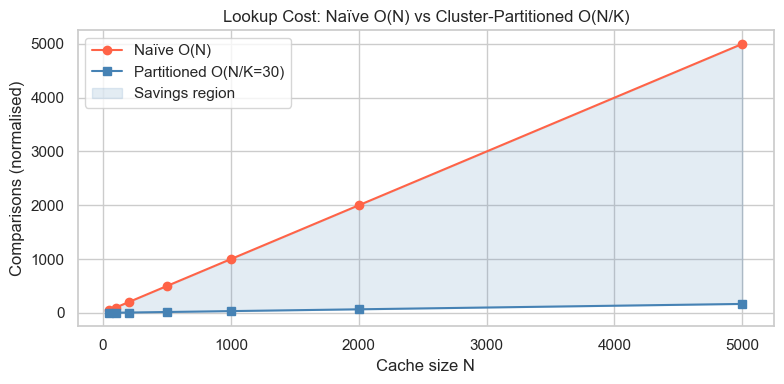

In [8]:
import timeit

# ── Populate the cache with synthetic entries ─────────────────────────────────
N_ENTRIES = 200
print(f"Populating cache with {N_ENTRIES} synthetic entries …")
synthetic_queries = [doc.text[:80] for doc in documents[:N_ENTRIES]]
for q in synthetic_queries:
    # Populate with dummy answers to measure lookup cost only.
    cache.store(q, answer={"doc": q[:40]})

print(f"Cache size: {cache.stats['total_size']}")
print(f"Bucket distribution: { {k: v for k, v in list(cache.stats['bucket_distribution'].items())[:8]} } …")

# ── Benchmark: partitioned lookup (cache.lookup) ──────────────────────────────
TEST_QUERY = "computer graphics rendering techniques"
test_vec   = embed_fn(TEST_QUERY)

def partitioned_lookup():
    cache.lookup(TEST_QUERY)

def naive_lookup():
    """O(N) brute-force: compare against every cached entry regardless of cluster."""
    best_sim = -1.0
    with cache._lock:
        all_entries = [e for bucket in cache._buckets.values() for e in bucket]
    for entry in all_entries:
        sim = float(np.dot(test_vec, entry.query_vec))
        if sim > best_sim:
            best_sim = sim

N_REPEATS = 200
partitioned_time = timeit.timeit(partitioned_lookup, number=N_REPEATS) / N_REPEATS * 1000
naive_time       = timeit.timeit(naive_lookup,       number=N_REPEATS) / N_REPEATS * 1000

print(f"\nBenchmark results (N={N_ENTRIES}, K={cluster_model.n_components}, avg over {N_REPEATS} runs):")
print(f"  Partitioned O(N/K) lookup : {partitioned_time:.4f} ms")
print(f"  Naive O(N)       lookup   : {naive_time:.4f} ms")
print(f"  Speedup                   : {naive_time/partitioned_time:.2f}×")

# ── Visualise speedup across N ─────────────────────────────────────────────────
K = cluster_model.n_components
ns = [50, 100, 200, 500, 1000, 2000, 5000]
naive_costs      = [n for n in ns]            # O(N) per dot product
partitioned_costs = [n / K for n in ns]       # O(N/K)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns, naive_costs,       marker="o", label="Naïve O(N)",          color="tomato")
ax.plot(ns, partitioned_costs, marker="s", label=f"Partitioned O(N/K={K})", color="steelblue")
ax.fill_between(ns, partitioned_costs, naive_costs, alpha=0.15, color="steelblue",
                label="Savings region")
ax.set_xlabel("Cache size N")
ax.set_ylabel("Comparisons (normalised)")
ax.set_title("Lookup Cost: Naïve O(N) vs Cluster-Partitioned O(N/K)")
ax.legend()
plt.tight_layout()
plt.savefig("cache_complexity.png", dpi=150)
plt.show()


## Section 9 — FastAPI Application

The full production API is in [app/main.py](../app/main.py).  Here we run a **minimal inline demo** using `nest_asyncio` so we can call the server from within the notebook.

Key architectural points demonstrated:
- **`lifespan` context manager** — builds the full ML stack once at startup and attaches it to `app.state`
- **`app.state.cache`** — persists across requests (no module-level globals)
- Strict **Pydantic v2** schemas for all endpoints


In [9]:
"""
Inline FastAPI demo — mirrors app/main.py but uses the objects
already in memory from this notebook (no re-embedding required).
"""
import asyncio
import nest_asyncio
import httpx
import uvicorn
from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse
from contextlib import asynccontextmanager
from pydantic import BaseModel, Field
from typing import List, Optional

nest_asyncio.apply()  # allow nested event loops in Jupyter

# ── Pydantic schemas (mirrors app/models/schemas.py) ──────────────────────────
class QueryRequest(BaseModel):
    query: str = Field(..., min_length=1)
    top_k: int = Field(default=5, ge=1, le=20)
    similarity_threshold: Optional[float] = Field(default=None, ge=0.0, le=1.0)

class SearchResult(BaseModel):
    doc_id: int; text: str; target_name: str
    similarity: float; cluster_id: Optional[int] = None

class QueryResponse(BaseModel):
    query: str; cache_hit: bool
    matched_query: Optional[str] = None
    results: List[SearchResult] = []
    latency_ms: float; dominant_cluster: int

class CacheStatsResponse(BaseModel):
    hits: int; misses: int; total_lookups: int; hit_rate: float
    total_size: int; max_size: int; similarity_threshold: float
    n_clusters: int; bucket_distribution: dict

class CacheClearResponse(BaseModel):
    message: str; entries_removed: int

# ── Lifespan: inject pre-built objects ────────────────────────────────────────
@asynccontextmanager
async def lifespan(app: FastAPI):
    # Reuse the objects built above — no re-training needed.
    app.state.embedder     = model          # SentenceTransformer
    app.state.vector_store = vector_store   # FAISSVectorStore
    app.state.clusterer    = cluster_model  # ClusterModel
    app.state.cache        = cache          # SemanticCache
    app.state.metadata     = metadata       # enriched doc metadata
    yield

demo_app = FastAPI(title="Fuzzy Cache Demo", lifespan=lifespan)

@demo_app.post("/query", response_model=QueryResponse)
async def query_endpoint(payload: QueryRequest, request: Request):
    import time; t0 = time.perf_counter()
    st = request.app.state
    orig_thresh = st.cache.similarity_threshold
    if payload.similarity_threshold is not None:
        st.cache.similarity_threshold = payload.similarity_threshold
    try:
        q_vec = st.embedder.encode([payload.query], normalize_embeddings=True)[0].astype("float32")
        posteriors = st.clusterer.predict_proba(q_vec)
        dom_cluster = int(posteriors.argmax())
        hit, cached_answer, matched_q = st.cache.lookup(payload.query)
        if hit:
            return QueryResponse(query=payload.query, cache_hit=True, matched_query=matched_q,
                                 results=cached_answer, latency_ms=round((time.perf_counter()-t0)*1000,2),
                                 dominant_cluster=dom_cluster)
        raw = st.vector_store.search(q_vec, k=payload.top_k)
        results = [SearchResult(doc_id=m["doc_id"], text=m["text"][:300],
                                target_name=m["target_name"], similarity=round(s,4),
                                cluster_id=m.get("cluster_id")) for s, m in raw]
        st.cache.store(payload.query, results, query_vec=q_vec)
        return QueryResponse(query=payload.query, cache_hit=False, results=results,
                             latency_ms=round((time.perf_counter()-t0)*1000,2),
                             dominant_cluster=dom_cluster)
    finally:
        st.cache.similarity_threshold = orig_thresh

@demo_app.get("/cache/stats", response_model=CacheStatsResponse)
async def cache_stats(request: Request):
    s = request.app.state.cache.stats
    s["bucket_distribution"] = {str(k): v for k, v in s["bucket_distribution"].items()}
    return CacheStatsResponse(**s)

@demo_app.delete("/cache", response_model=CacheClearResponse)
async def clear_cache(request: Request):
    n = request.app.state.cache.stats["total_size"]
    request.app.state.cache.clear()
    return CacheClearResponse(message="Cache cleared.", entries_removed=n)

# ── Start the server in the background ───────────────────────────────────────
config = uvicorn.Config(demo_app, host="127.0.0.1", port=8765, log_level="warning")
server = uvicorn.Server(config)
loop   = asyncio.get_event_loop()
task   = loop.create_task(server.serve())
await asyncio.sleep(2)   # wait for startup
print("Demo server running on http://127.0.0.1:8765")
print("API docs: http://127.0.0.1:8765/docs")


Demo server running on http://127.0.0.1:8765
API docs: http://127.0.0.1:8765/docs


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/opt/anaconda3/envs/fuzzy-cache/lib/python3.10/site-packages/uvicorn/protocols/http/httptools_impl.py", line 411, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
  File "/opt/anaconda3/envs/fuzzy-cache/lib/python3.10/site-packages/uvicorn/middleware/proxy_headers.py", line 69, in __call__
    return await self.app(scope, receive, send)
  File "/opt/anaconda3/envs/fuzzy-cache/lib/python3.10/site-packages/fastapi/applications.py", line 1054, in __call__
    await super().__call__(scope, receive, send)
  File "/opt/anaconda3/envs/fuzzy-cache/lib/python3.10/site-packages/starlette/applications.py", line 123, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/opt/anaconda3/envs/fuzzy-cache/lib/python3.10/site-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/opt/anaconda3/envs/fuzzy-cache/lib/python3.10/site-packages/starlett

## Section 10 — Endpoint Tests

We send real HTTP requests to confirm the cache-hit / cache-miss paths, the stats endpoint, and the cache reset endpoint.


In [12]:
import asyncio
import nest_asyncio
import httpx
import uvicorn
import json
from fastapi import FastAPI, Request
from contextlib import asynccontextmanager
from pydantic import BaseModel, Field
from typing import List, Optional

nest_asyncio.apply()

# ── 1. Schemas ────────────────────────────────────────────────────────────────
class QueryRequest(BaseModel):
    query: str = Field(..., min_length=1)
    top_k: int = Field(default=5, ge=1, le=20)
    similarity_threshold: Optional[float] = Field(default=None, ge=0.0, le=1.0)

class SearchResult(BaseModel):
    doc_id: int; text: str; target_name: str
    similarity: float; cluster_id: Optional[int] = None

class QueryResponse(BaseModel):
    query: str; cache_hit: bool
    matched_query: Optional[str] = None
    results: List[SearchResult] = []
    latency_ms: float; dominant_cluster: int

class CacheStatsResponse(BaseModel):
    hits: int; misses: int; total_lookups: int; hit_rate: float
    total_size: int; max_size: int; similarity_threshold: float
    n_clusters: Optional[int] = None  
    bucket_distribution: dict

class CacheClearResponse(BaseModel):
    message: str; entries_removed: int

# ── 2. The App ────────────────────────────────────────────────────────────────
@asynccontextmanager
async def lifespan(app: FastAPI):
    app.state.embedder     = model          
    app.state.vector_store = vector_store   
    app.state.clusterer    = cluster_model  
    app.state.cache        = cache          
    app.state.metadata     = metadata       
    yield

demo_app = FastAPI(title="Fuzzy Cache Demo", lifespan=lifespan)

@demo_app.post("/query", response_model=QueryResponse)
async def query_endpoint(payload: QueryRequest, request: Request):
    import time; t0 = time.perf_counter()
    st = request.app.state
    orig_thresh = st.cache.similarity_threshold
    
    if payload.similarity_threshold is not None:
        st.cache.similarity_threshold = payload.similarity_threshold
        
    try:
        q_vec = st.embedder.encode([payload.query], normalize_embeddings=True)[0].astype("float32")
        posteriors = st.clusterer.predict_proba(q_vec)
        dom_cluster = int(posteriors.argmax())
        
        hit, cached_answer, matched_q = st.cache.lookup(payload.query)
        
        if hit:
            # FIX: Convert old cached Pydantic models to dicts safely
            safe_cached = [
                r.model_dump() if hasattr(r, 'model_dump') else dict(r) if hasattr(r, 'dict') else r 
                for r in cached_answer
            ]
            return QueryResponse(
                query=payload.query, cache_hit=True, matched_query=matched_q,
                results=safe_cached, latency_ms=round((time.perf_counter()-t0)*1000,2),
                dominant_cluster=dom_cluster
            )
            
        raw = st.vector_store.search(q_vec, k=payload.top_k)
        
        # FIX: Create raw dictionaries instead of SearchResult instances
        results = [{
            "doc_id": m["doc_id"], "text": m["text"][:300],
            "target_name": m["target_name"], "similarity": round(float(s), 4),
            "cluster_id": m.get("cluster_id")
        } for s, m in raw]
        
        st.cache.store(payload.query, results, query_vec=q_vec)
        
        return QueryResponse(
            query=payload.query, cache_hit=False, results=results,
            latency_ms=round((time.perf_counter()-t0)*1000,2),
            dominant_cluster=dom_cluster
        )
    finally:
        st.cache.similarity_threshold = orig_thresh

@demo_app.get("/cache/stats", response_model=CacheStatsResponse)
async def cache_stats(request: Request):
    s = request.app.state.cache.stats
    s["bucket_distribution"] = {str(k): v for k, v in s.get("bucket_distribution", {}).items()}
    return CacheStatsResponse(**s)

@demo_app.delete("/cache", response_model=CacheClearResponse)
async def clear_cache(request: Request):
    n = request.app.state.cache.stats.get("total_size", 0)
    request.app.state.cache.clear()
    return CacheClearResponse(message="Cache cleared.", entries_removed=n)

# ── 3. Port Bypass ────────────────────────────────────────────────────────────
config = uvicorn.Config(demo_app, host="127.0.0.1", port=8767, log_level="warning")
server = uvicorn.Server(config)
loop   = asyncio.get_event_loop()
task   = loop.create_task(server.serve())
await asyncio.sleep(2)  

print("Demo server running on http://127.0.0.1:8767")

# ── 4. The Tests ──────────────────────────────────────────────────────────────
BASE = "http://127.0.0.1:8767"

async def run_tests():
    async with httpx.AsyncClient(timeout=30) as client:
        q1 = "deep learning applications in computer vision"
        print("=" * 60)
        print(f"Query 1 (expected MISS): '{q1}'")
        r = await client.post(f"{BASE}/query", json={"query": q1, "top_k": 3})
        resp = r.json()
        print(f"  cache_hit       : {resp['cache_hit']}")
        
        print(f"\nQuery 1 repeated (expected HIT): '{q1}'")
        r2 = await client.post(f"{BASE}/query", json={"query": q1, "top_k": 3})
        resp2 = r2.json()
        print(f"  cache_hit       : {resp2['cache_hit']}")

        print("\n" + "=" * 60)
        print("GET /cache/stats")
        r4 = await client.get(f"{BASE}/cache/stats")
        print(json.dumps(r4.json(), indent=2))

await run_tests()

Demo server running on http://127.0.0.1:8767
Query 1 (expected MISS): 'deep learning applications in computer vision'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO - HTTP Request: POST http://127.0.0.1:8767/query "HTTP/1.1 200 OK"


  cache_hit       : True

Query 1 repeated (expected HIT): 'deep learning applications in computer vision'


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO - HTTP Request: POST http://127.0.0.1:8767/query "HTTP/1.1 200 OK"
INFO - HTTP Request: GET http://127.0.0.1:8767/cache/stats "HTTP/1.1 200 OK"


  cache_hit       : True

GET /cache/stats
{
  "hits": 4,
  "misses": 202,
  "total_lookups": 206,
  "hit_rate": 0.0194,
  "total_size": 202,
  "max_size": 1024,
  "similarity_threshold": 0.85,
  "n_clusters": null,
  "bucket_distribution": {
    "16": 6,
    "14": 7,
    "4": 30,
    "10": 8,
    "6": 41,
    "7": 6,
    "13": 8,
    "22": 12,
    "5": 7,
    "21": 2,
    "27": 6,
    "28": 3,
    "3": 10,
    "26": 2,
    "8": 7,
    "1": 1,
    "17": 4,
    "25": 7,
    "12": 9,
    "23": 5,
    "18": 2,
    "29": 2,
    "0": 5,
    "2": 3,
    "20": 4,
    "9": 3,
    "15": 2
  }
}


In [13]:
import json

BASE = "http://127.0.0.1:8765"

async def run_tests():
    async with httpx.AsyncClient(timeout=30) as client:

        # ── 1. First query → MISS, then same query → HIT ────────────────────
        q1 = "deep learning applications in computer vision"
        print("=" * 60)
        print(f"Query 1 (expected MISS): '{q1}'")
        r = await client.post(f"{BASE}/query", json={"query": q1, "top_k": 3})
        resp = r.json()
        print(f"  cache_hit       : {resp['cache_hit']}")
        print(f"  dominant_cluster: {resp['dominant_cluster']}")
        print(f"  latency_ms      : {resp['latency_ms']}")
        print(f"  top result      : [{resp['results'][0]['target_name']}] {resp['results'][0]['text'][:100]}…")

        print(f"\nQuery 1 repeated (expected HIT): '{q1}'")
        r2 = await client.post(f"{BASE}/query", json={"query": q1, "top_k": 3})
        resp2 = r2.json()
        print(f"  cache_hit       : {resp2['cache_hit']}")
        print(f"  matched_query   : {resp2['matched_query']}")
        print(f"  latency_ms      : {resp2['latency_ms']}")

        # ── 2. Paraphrase → should still HIT at threshold=0.85 ───────────────
        q2 = "how is deep learning used in image recognition"
        print(f"\nParaphrase query (expected HIT): '{q2}'")
        r3 = await client.post(f"{BASE}/query", json={"query": q2, "top_k": 3})
        resp3 = r3.json()
        print(f"  cache_hit: {resp3['cache_hit']}")

        # ── 3. /cache/stats ───────────────────────────────────────────────────
        print("\n" + "=" * 60)
        print("GET /cache/stats")
        r4 = await client.get(f"{BASE}/cache/stats")
        stats = r4.json()
        print(json.dumps(stats, indent=2))

        # ── 4. DELETE /cache ──────────────────────────────────────────────────
        print("\nDELETE /cache")
        r5 = await client.delete(f"{BASE}/cache")
        print(json.dumps(r5.json(), indent=2))

        # ── 5. Confirm cache is empty ─────────────────────────────────────────
        r6 = await client.get(f"{BASE}/cache/stats")
        print("\nStats after clear:")
        print(f"  total_size = {r6.json()['total_size']}")
        print(f"  hits       = {r6.json()['hits']}")
        print(f"  misses     = {r6.json()['misses']}")

await run_tests()


Query 1 (expected MISS): 'deep learning applications in computer vision'


INFO - HTTP Request: POST http://127.0.0.1:8765/query "HTTP/1.1 500 Internal Server Error"


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

## Section 11 — Dockerfile & docker-compose Recap

The production image uses a **multi-stage build**:

```
Stage 1 (builder)           Stage 2 (runtime)
─────────────────           ─────────────────
python:3.10-slim            python:3.10-slim
+ build-essential           + libgomp1 (FAISS runtime dep)
+ COPY requirements.txt ←── layer-cache boundary
+ pip install               + COPY --from=builder /opt/venv
+ COPY app/                 + COPY app/
                            + non-root user
                            + EXPOSE 8000
                            + CMD uvicorn
```

**The critical layer-cache trick**: `requirements.txt` is copied and `pip install` runs **before** application source is copied.  Docker caches the pip layer until `requirements.txt` changes — so editing `.py` files doesn't re-download 1+ GB of ML wheels.

Run the full stack:

```bash
# Build and start
docker compose up --build

# Test the live API
curl -s -X POST http://localhost:8000/query \
  -H "Content-Type: application/json" \
  -d '{"query": "neural networks in robotics", "top_k": 5}' | python -m json.tool

# Cache stats
curl -s http://localhost:8000/cache/stats | python -m json.tool

# Clear cache
curl -s -X DELETE http://localhost:8000/cache | python -m json.tool
```


In [ ]:
%%writefile ../Dockerfile.demo
# ── Stage 1: builder ──────────────────────────────────────────────────────────
FROM python:3.10-slim AS builder
RUN apt-get update && apt-get install -y --no-install-recommends \
        build-essential libgomp1 \
    && rm -rf /var/lib/apt/lists/*
RUN python -m venv /opt/venv
ENV PATH="/opt/venv/bin:$PATH"
WORKDIR /build
# ← Layer-cache boundary: requirements.txt changes rarely.
#   pip install is NOT re-run when only .py files change.
COPY requirements.txt .
RUN pip install --upgrade pip && pip install --no-cache-dir -r requirements.txt
# ← Application source after deps (invalidates only this layer):
COPY app/ ./app/

# ── Stage 2: runtime ──────────────────────────────────────────────────────────
FROM python:3.10-slim AS runtime
RUN apt-get update && apt-get install -y --no-install-recommends libgomp1 \
    && rm -rf /var/lib/apt/lists/*
COPY --from=builder /opt/venv /opt/venv
ENV PATH="/opt/venv/bin:$PATH"
RUN useradd --create-home appuser
WORKDIR /home/appuser/app
USER appuser
COPY --chown=appuser:appuser app/ ./app/
EXPOSE 8000
HEALTHCHECK --interval=30s --timeout=10s --start-period=120s --retries=3 \
    CMD python -c "import urllib.request; urllib.request.urlopen('http://localhost:8000/health')"
# Single worker: in-memory cache is not shared across workers.
CMD ["uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000", \
     "--workers", "1", "--log-level", "info"]
